Using TensorFlow version: 2.21.0
Total vocabulary size: 82 words
X shape: (83, 16)
y shape: (83,)
Max sequence length: 17

Training RNN...


/Users/rehanhussain/anaconda3/envs/cifar_env/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training LSTM...
Training GRU...
Training complete!


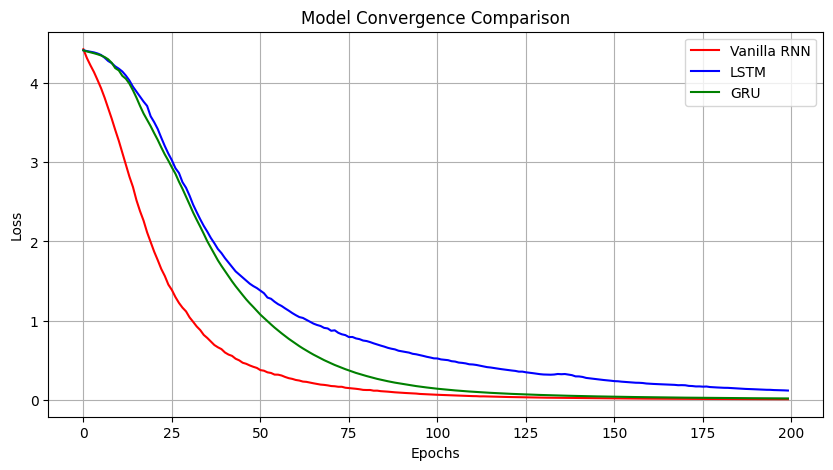


Results:
----------------------------------------
RNN Generation : artificial intelligence is driving a massive shift across modern technology landscapes data
LSTM Generation: artificial intelligence is driving a massive shift across modern technology landscapes landscapes
GRU Generation : artificial intelligence is driving a massive shift across modern technology landscapes landscapes
----------------------------------------


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import re

print("Using TensorFlow version:", tf.__version__)

# Custom paragraph about deep learning sequence models
corpus = """
Artificial intelligence is driving a massive shift across modern technology landscapes. 
Deep learning architectures allow machines to process complex sequential datasets effortlessly.
While a basic recurrent neural network works well for short phrases, it fails on long text sequences.
Gated architectures like long short term memory networks resolve these severe memory limitations.
The gated recurrent unit offers a streamlined structural alternative that trains much faster.
By studying next word prediction patterns, sequence models gradually absorb human grammar rules.
Advanced text generation frameworks can generate remarkably coherent sentences given enough data.
"""

# Clean up the text by lowering the case and pulling out punctuation
cleaned_text = corpus.lower().strip()
cleaned_text = re.sub(r'[^\w\s\n]', '', cleaned_text)

# Tokenize words to numbers
tokenizer = Tokenizer()
tokenizer.fit_on_texts([cleaned_text])
total_words = len(tokenizer.word_index) + 1

print(f"Total vocabulary size: {total_words} words")

# Build sliding-window n-gram sequences for training
input_sequences = []
for line in cleaned_text.split('\n'):
    if not line.strip():
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

# Pad everything from the front so all sequences are the same length
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

# Split data into features (X) and target labels (y)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Max sequence length:", max_len)

# Hyperparameters based on project tasks
embedding_dim = 64
hidden_units = 128
epochs = 200
input_length = max_len - 1

# Model 1: Basic Vanilla RNN
rnn_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=input_length),
    SimpleRNN(hidden_units),
    Dense(total_words, activation='softmax')
])

# Model 2: Standard LSTM
lstm_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=input_length),
    LSTM(hidden_units),
    Dense(total_words, activation='softmax')
])

# Model 3: Faster GRU variant
gru_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=input_length),
    GRU(hidden_units),
    Dense(total_words, activation='softmax')
])

# Compile all three models using standard Adam and Categorical Crossentropy
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the models (keeping verbose=0 to hide massive training logs)
print("\nTraining RNN...")
rnn_history = rnn_model.fit(X, y, epochs=epochs, verbose=0)

print("Training LSTM...")
lstm_history = lstm_model.fit(X, y, epochs=epochs, verbose=0)

print("Training GRU...")
gru_history = gru_model.fit(X, y, epochs=epochs, verbose=0)

print("Training complete!")

# Plot the loss histories to see which model converged fastest
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['loss'], label='Vanilla RNN', color='red')
plt.plot(lstm_history.history['loss'], label='LSTM', color='blue')
plt.plot(gru_history.history['loss'], label='GRU', color='green')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Convergence Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Text generation helper function
def generate_text(model, seed_text, next_words=10):
    current_text = seed_text
    for _ in range(next_words):
        # Numeric transform & padding
        token_list = tokenizer.texts_to_sequences([current_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        
        # Predict probability distributions and grab the highest index
        predictions = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predictions, axis=-1)[0]

        # Look up the integer token back to its word equivalent
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break
        
        current_text += " " + predicted_word
    return current_text

# Let's test the models
prompt = "artificial intelligence"
print("\nResults:")
print("-" * 40)
print("RNN Generation :", generate_text(rnn_model, prompt, next_words=10))
print("LSTM Generation:", generate_text(lstm_model, prompt, next_words=10))
print("GRU Generation :", generate_text(gru_model, prompt, next_words=10))
print("-" * 40)